# 🐟 Multiclass Fish Image Classification — PyTorch + CUDA 12.5
### CNN from Scratch + VGG16 + ResNet50 + MobileNet + InceptionV3 + EfficientNetB0
---
> ⚡ Uses PyTorch with CUDA 12.5 — full GPU support on Windows

## ✅ Step 1 — Install Packages

In [6]:
import sys

# Install PyTorch with CUDA 12.1 wheels (compatible with CUDA 12.5)
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# # Install other packages
!{sys.executable} -m pip install numpy==1.24.3
# !{sys.executable} -m pip install matplotlib==3.7.1
# !{sys.executable} -m pip install seaborn==0.12.2
# !{sys.executable} -m pip install scikit-learn==1.2.2
# !{sys.executable} -m pip install pillow==9.5.0
# !{sys.executable} -m pip install plotly==5.14.1
# !{sys.executable} -m pip install pandas==2.0.3
# !{sys.executable} -m pip install ipywidgets==8.0.6
# !{sys.executable} -m pip install streamlit==1.28.0
# !{sys.executable} -m pip install tqdm

print('\n✅ All packages installed! Restart kernel now → Kernel → Restart Kernel')

     ---------------------------------------- 14.8/14.8 MB 2.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4

✅ All packages installed! Restart kernel now → Kernel → Restart Kernel


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\sarav\\Documents\\CV_project\\Fish_classification\\env\\Lib\\site-packages\\~-mpy\\random\\mtrand.cp310-win_amd64.pyd'
Check the permissions.

You should consider upgrading via the 'c:\Users\sarav\Documents\CV_project\Fish_classification\env\Scripts\python.exe -m pip install --upgrade pip' command.


## ✅ Step 2 — Verify GPU

In [2]:
import torch

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())

if torch.cuda.is_available():
    print('GPU name        :', torch.cuda.get_device_name(0))
    print('CUDA version    :', torch.version.cuda)
    print('VRAM            :', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')
    DEVICE = torch.device('cuda')
    print('\n✅ GPU is ready!')
else:
    DEVICE = torch.device('cpu')
    print('\n⚠️  Running on CPU')

print('Using device    :', DEVICE)

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU name        : NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version    : 12.1
VRAM            : 4.0 GB

✅ GPU is ready!
Using device    : cuda


In [9]:
# Uninstall conflicting versions
!pip uninstall numpy pandas -y

# Install compatible versions together
!pip install numpy==1.24.3
!pip install pandas==2.0.3

Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
Found existing installation: pandas 2.0.3
Uninstalling pandas-2.0.3:
  Successfully uninstalled pandas-2.0.3


  Using cached numpy-1.24.3-cp310-cp310-win_amd64.whl (14.8 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seaborn 0.12.2 requires pandas>=0.25, which is not installed.
You should consider upgrading via the 'C:\Users\sarav\Documents\CV_project\Fish_classification\env\Scripts\python.exe -m pip install --upgrade pip' command.


  Using cached pandas-2.0.3-cp310-cp310-win_amd64.whl (10.7 MB)


You should consider upgrading via the 'C:\Users\sarav\Documents\CV_project\Fish_classification\env\Scripts\python.exe -m pip install --upgrade pip' command.


## ✅ Step 3 — Import Libraries

In [1]:
import os
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

print('All libraries imported ✅')

All libraries imported ✅


## ✅ Step 4 — Configuration
> 👇 Only change `DATASET_DIR` if needed

In [2]:
# ── Dataset path ─────────────────────────────────────────────
DATASET_DIR = r'C:\Users\sarav\Documents\CV_project\Fish_classification\data\train'

# ── Hyperparameters (optimized for 4GB VRAM) ─────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 16       # safe for 4GB VRAM
EPOCHS         = 20
LEARNING_RATE  = 0.001
NUM_WORKERS    = 2
SEED           = 42

MODEL_SAVE_DIR = 'saved_models'
RESULTS_DIR    = 'results'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Verify dataset ───────────────────────────────────────────
if not os.path.exists(DATASET_DIR):
    print(f'❌ Dataset not found: {DATASET_DIR}')
else:
    classes = sorted([d for d in os.listdir(DATASET_DIR)
                      if os.path.isdir(os.path.join(DATASET_DIR, d))])
    print(f'✅ Dataset found!')
    print(f'   Path    : {DATASET_DIR}')
    print(f'   Classes : {len(classes)}')
    print()
    for cls in classes:
        n = len(os.listdir(os.path.join(DATASET_DIR, cls)))
        print(f'   {cls:<30} {n} images')

✅ Dataset found!
   Path    : C:\Users\sarav\Documents\CV_project\Fish_classification\data\train
   Classes : 11

   animal fish                    1096 images
   animal fish bass               30 images
   fish sea_food black_sea_sprat  569 images
   fish sea_food gilt_head_bream  566 images
   fish sea_food hourse_mackerel  573 images
   fish sea_food red_mullet       579 images
   fish sea_food red_sea_bream    571 images
   fish sea_food sea_bass         538 images
   fish sea_food shrimp           576 images
   fish sea_food striped_red_mullet 547 images
   fish sea_food trout            580 images


## ✅ Step 5 — Data Preprocessing & Augmentation

In [4]:
# ── Transforms ───────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet mean
                         std=[0.229, 0.224, 0.225])     # ImageNet std
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Load full dataset then split 80/20 ───────────────────────
full_dataset = datasets.ImageFolder(DATASET_DIR)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

total       = len(full_dataset)
val_size    = int(0.2 * total)
train_size  = total - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply transforms separately
train_dataset.dataset = datasets.ImageFolder(DATASET_DIR, transform=train_transforms)
val_dataset_clean     = datasets.ImageFolder(DATASET_DIR, transform=val_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(torch.utils.data.Subset(val_dataset_clean, val_dataset.indices),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Save class names
with open(os.path.join(MODEL_SAVE_DIR, 'class_names.json'), 'w') as f:
    json.dump(CLASS_NAMES, f)

print(f'Total images       : {total}')
print(f'Training samples   : {train_size}')
print(f'Validation samples : {val_size}')
print(f'Number of classes  : {NUM_CLASSES}')
print(f'Batch size         : {BATCH_SIZE}')
print(f'Classes            : {CLASS_NAMES}')

Total images       : 6225
Training samples   : 4980
Validation samples : 1245
Number of classes  : 11
Batch size         : 16
Classes            : ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']


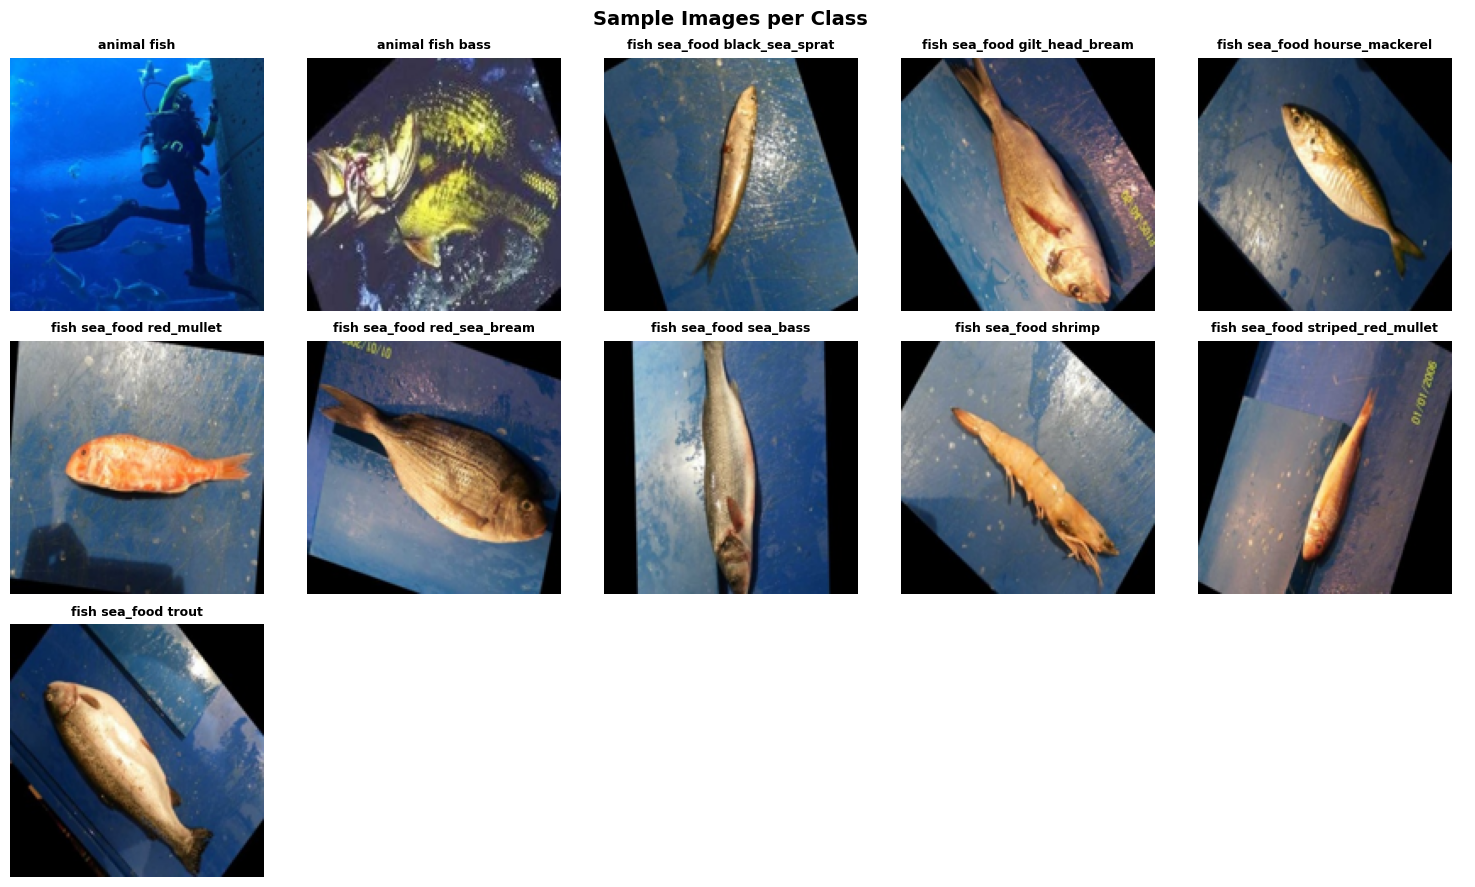

In [5]:
# ── Visualize sample images ───────────────────────────────────
n_cols = min(5, NUM_CLASSES)
n_rows = (NUM_CLASSES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = np.array(axes).flatten()

for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_DIR, cls)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        img = Image.open(os.path.join(folder, imgs[0])).resize((150, 150))
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=120)
plt.show()

## ✅ Step 6 — Helper Functions

In [9]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


In [10]:
# ── Global stores ─────────────────────────────────────────────
all_histories = {}
all_reports   = {}
model_map     = {}


# ── Training function ─────────────────────────────────────────
def train_model(model, model_name, epochs=EPOCHS, lr=LEARNING_RATE):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, verbose=True)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_acc   = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    early_stop_patience = 5

    print(f'\n{"="*55}')
    print(f'  Training : {model_name}')
    print(f'  Params   : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'  Device   : {DEVICE}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        # ── Train phase ──
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * inputs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # ── Val phase ──
        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs  = model(inputs)
                loss     = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # ── Metrics ──
        t_loss = train_loss / train_size
        t_acc  = train_correct / train_size
        v_loss = val_loss / val_size
        v_acc  = val_correct / val_size

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        scheduler.step(v_loss)

        print(f'Epoch {epoch+1:02d}/{epochs} | '
              f'Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')

        # ── Save best model ──
        if v_acc > best_acc:
            best_acc     = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(),
                       os.path.join(MODEL_SAVE_DIR, f'{model_name}.pth'))
            patience_counter = 0
        else:
            patience_counter += 1

        # ── Early stopping ──
        if patience_counter >= early_stop_patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_weights)
    print(f'  Best Val Accuracy : {best_acc:.4f}')

    all_histories[model_name] = history
    model_map[model_name]     = model
    return model, history


# ── Plot history ──────────────────────────────────────────────
def plot_history(model_name):
    hist = all_histories[model_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(hist['train_acc'], label='Train', color='royalblue', linewidth=2)
    axes[0].plot(hist['val_acc'],   label='Val',   color='tomato',    linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    best_val = max(hist['val_acc'])
    axes[0].annotate(f'Best: {best_val:.4f}',
                     xy=(np.argmax(hist['val_acc']), best_val),
                     xytext=(5, -15), textcoords='offset points',
                     color='tomato', fontweight='bold')

    # Loss
    axes[1].plot(hist['train_loss'], label='Train', color='royalblue', linewidth=2)
    axes[1].plot(hist['val_loss'],   label='Val',   color='tomato',    linewidth=2, linestyle='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f'{model_name}_history.png')
    plt.savefig(path, dpi=120)
    plt.show()
    print(f'  Saved → {path}')


# ── Evaluate model ────────────────────────────────────────────
def evaluate_model(model, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f'Evaluating {model_name}'):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    report = classification_report(
        all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True
    )
    print(f'\n── {model_name} — Classification Report ──')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig_size = max(8, NUM_CLASSES)
    plt.figure(figsize=(fig_size, fig_size - 2))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', linewidths=0.4)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f'{model_name}_confusion_matrix.png')
    plt.savefig(path, dpi=120)
    plt.show()
    print(f'  Saved → {path}')

    all_reports[model_name] = report
    return report


# ── Free GPU memory between models ───────────────────────────
def clear_gpu():
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    print('GPU cache cleared ✅')


print('Helper functions ready ✅')

Helper functions ready ✅


## ✅ Step 7 — Model 1: CNN from Scratch

In [11]:
class CNNScratch(nn.Module):
    def __init__(self, num_classes):
        super(CNNScratch, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_scratch = CNNScratch(NUM_CLASSES)
print(cnn_scratch)
print(f'\nTotal params: {sum(p.numel() for p in cnn_scratch.parameters()):,}')

CNNScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [12]:
cnn_scratch, _ = train_model(cnn_scratch, 'CNN_Scratch')


  Training : CNN_Scratch
  Params   : 526,603
  Device   : cuda


Epoch 01/20 | Train Loss: 1.5630 Acc: 0.4333 | Val Loss: 0.9896 Acc: 0.6884


Epoch 02/20 | Train Loss: 1.0702 Acc: 0.6183 | Val Loss: 0.6662 Acc: 0.7896


Epoch 03/20 | Train Loss: 0.8541 Acc: 0.6942 | Val Loss: 0.4321 Acc: 0.8988


Epoch 04/20 | Train Loss: 0.7229 Acc: 0.7392 | Val Loss: 0.4021 Acc: 0.8811


...

Epoch 16/20 | Train Loss: 0.2449 Acc: 0.9147 | Val Loss: 0.0995 Acc: 0.9719


Epoch 17/20 | Train Loss: 0.2308 Acc: 0.9251 | Val Loss: 0.1420 Acc: 0.9454


Epoch 18/20 | Train Loss: 0.2203 Acc: 0.9271 | Val Loss: 0.0816 Acc: 0.9807


Epoch 19/20 | Train Loss: 0.1930 Acc: 0.9335 | Val Loss: 0.0774 Acc: 0.9783


Epoch 20/20 | Train Loss: 0.2031 Acc: 0.9359 | Val Loss: 0.1158 Acc: 0.9663
  Best Val Accuracy : 0.9807


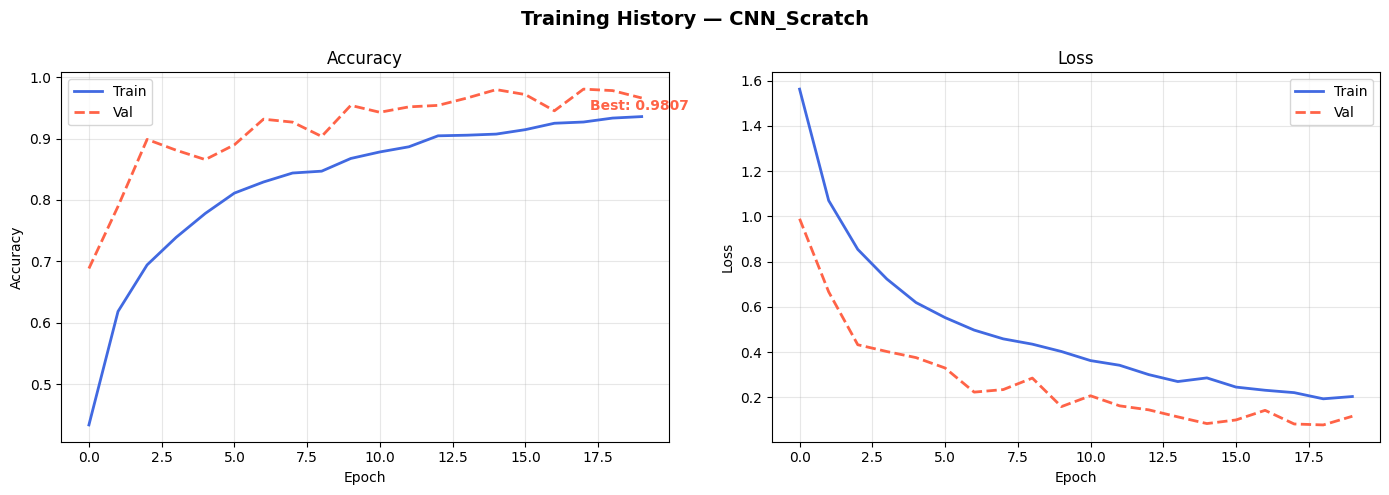

  Saved → results\CNN_Scratch_history.png


In [13]:
plot_history('CNN_Scratch')

Evaluating CNN_Scratch: 100%|██████████| 78/78 [00:11<00:00,  6.60it/s]



── CNN_Scratch — Classification Report ──
                                  precision    recall  f1-score   support

                     animal fish       0.96      1.00      0.98       214
                animal fish bass       0.00      0.00      0.00         9
   fish sea_food black_sea_sprat       1.00      1.00      1.00       125
   fish sea_food gilt_head_bream       0.99      0.89      0.94        94
   fish sea_food hourse_mackerel       1.00      1.00      1.00       104
        fish sea_food red_mullet       1.00      0.99      1.00       117
     fish sea_food red_sea_bream       0.96      1.00      0.98       117
          fish sea_food sea_bass       0.96      0.99      0.97       108
            fish sea_food shrimp       0.98      1.00      0.99       123
fish sea_food striped_red_mullet       0.99      0.97      0.98       119
             fish sea_food trout       1.00      1.00      1.00       115

                        accuracy                           0.98    

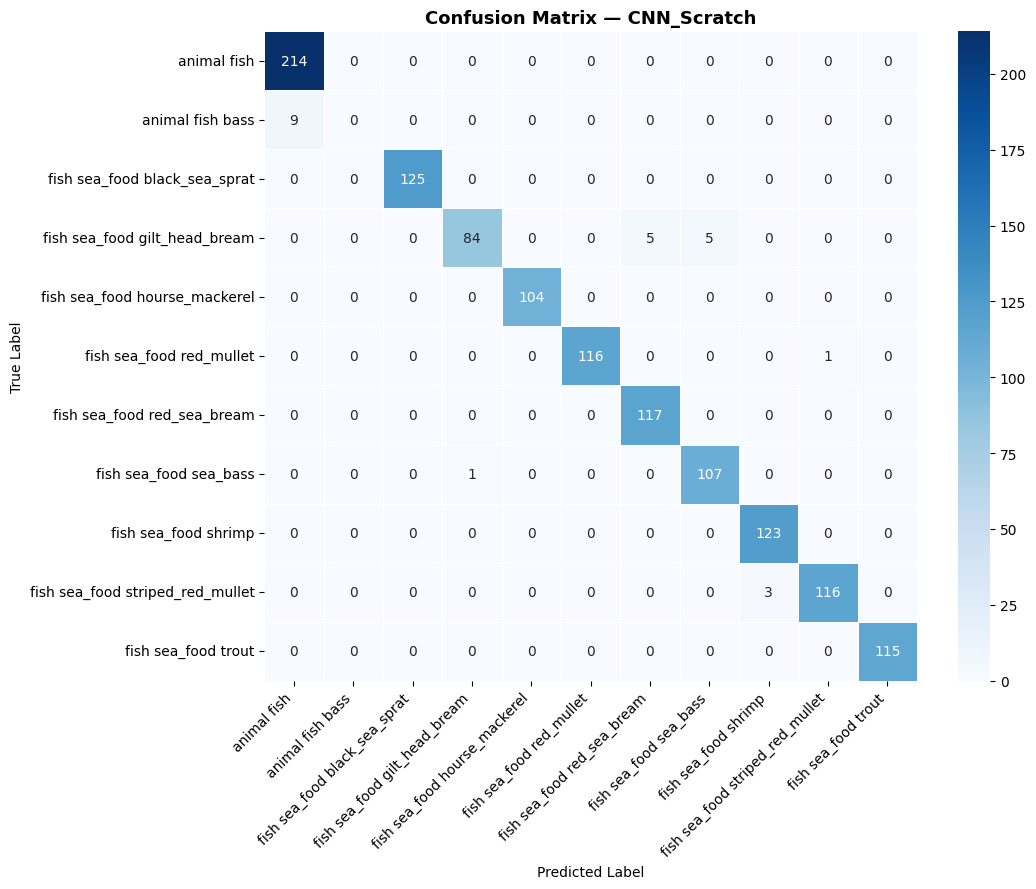

  Saved → results\CNN_Scratch_confusion_matrix.png
GPU cache cleared ✅


In [14]:
evaluate_model(cnn_scratch, 'CNN_Scratch')
clear_gpu()

## ✅ Step 8 — Model 2: VGG16

In [15]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# Freeze all layers
for param in vgg16.parameters():
    param.requires_grad = False
# Replace classifier
vgg16.classifier[6] = nn.Linear(4096, NUM_CLASSES)

vgg16, _ = train_model(vgg16, 'VGG16')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\sarav/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [02:53<00:00, 3.20MB/s] 



  Training : VGG16
  Params   : 45,067
  Device   : cuda


Epoch 01/20 | Train Loss: 0.6340 Acc: 0.7857 | Val Loss: 0.1938 Acc: 0.9526


Epoch 02/20 | Train Loss: 0.3858 Acc: 0.8602 | Val Loss: 0.1438 Acc: 0.9590


Epoch 03/20 | Train Loss: 0.3278 Acc: 0.8876 | Val Loss: 0.1758 Acc: 0.9382


...

Epoch 16/20 | Train Loss: 0.2862 Acc: 0.9096 | Val Loss: 0.0941 Acc: 0.9775


Epoch 17/20 | Train Loss: 0.3155 Acc: 0.9010 | Val Loss: 0.1067 Acc: 0.9719


Epoch 18/20 | Train Loss: 0.3392 Acc: 0.9032 | Val Loss: 0.1536 Acc: 0.9510


Epoch 19/20 | Train Loss: 0.3092 Acc: 0.9030 | Val Loss: 0.1046 Acc: 0.9767


Epoch 20/20 | Train Loss: 0.2862 Acc: 0.9114 | Val Loss: 0.0864 Acc: 0.9775
  Early stopping at epoch 20
  Best Val Accuracy : 0.9783


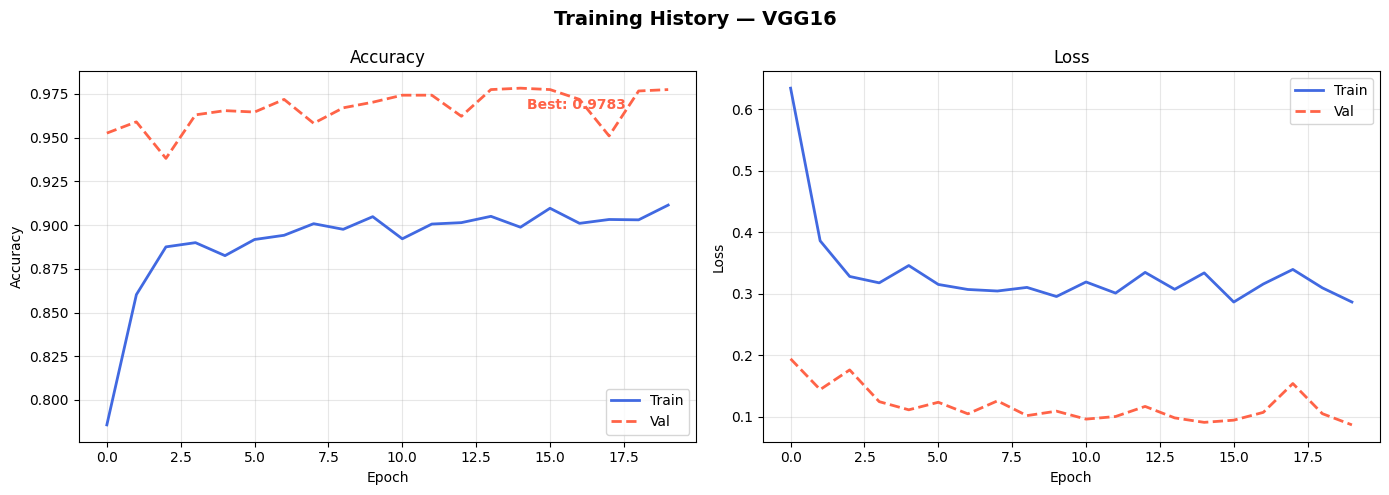

  Saved → results\VGG16_history.png


In [16]:
plot_history('VGG16')

Evaluating VGG16: 100%|██████████| 78/78 [00:18<00:00,  4.31it/s]



── VGG16 — Classification Report ──
                                  precision    recall  f1-score   support

                     animal fish       0.97      1.00      0.98       214
                animal fish bass       1.00      0.33      0.50         9
   fish sea_food black_sea_sprat       0.95      0.98      0.96       125
   fish sea_food gilt_head_bream       0.99      0.96      0.97        94
   fish sea_food hourse_mackerel       0.95      0.96      0.96       104
        fish sea_food red_mullet       0.98      1.00      0.99       117
     fish sea_food red_sea_bream       1.00      1.00      1.00       117
          fish sea_food sea_bass       0.99      0.96      0.98       108
            fish sea_food shrimp       1.00      0.99      1.00       123
fish sea_food striped_red_mullet       0.97      0.98      0.97       119
             fish sea_food trout       0.99      0.97      0.98       115

                        accuracy                           0.98      1245

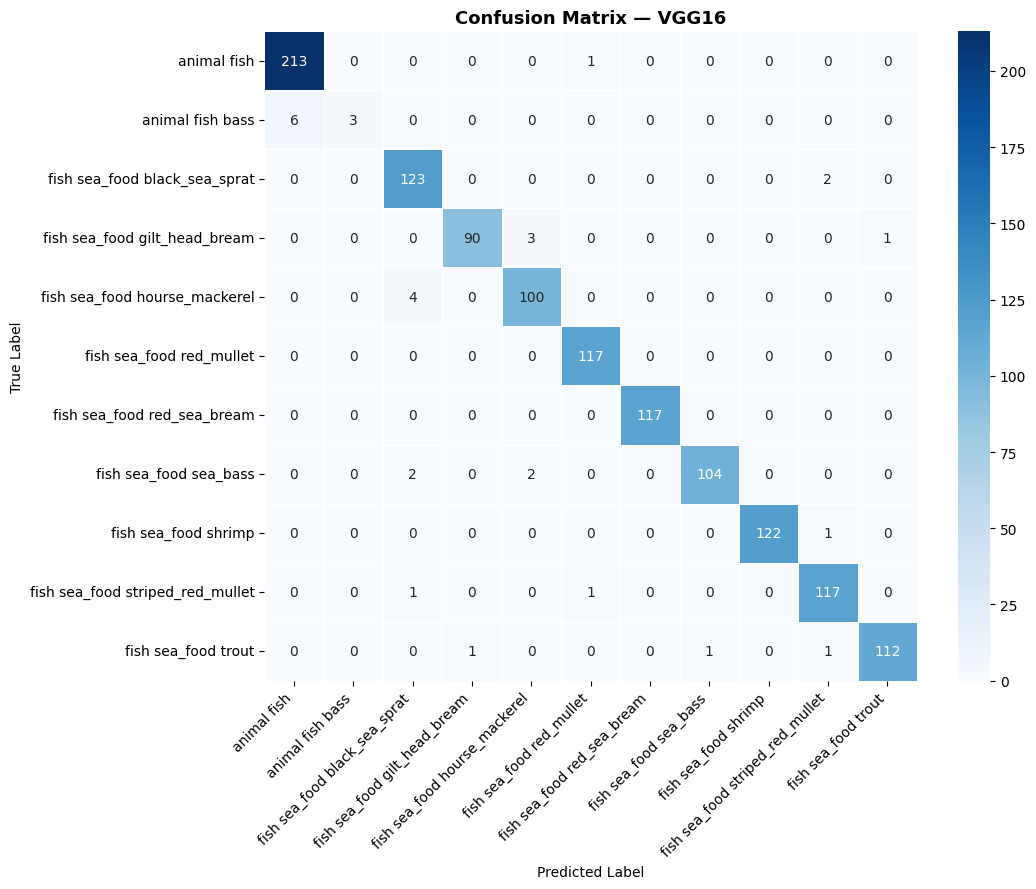

  Saved → results\VGG16_confusion_matrix.png
GPU cache cleared ✅


In [17]:
evaluate_model(vgg16, 'VGG16')
clear_gpu()

## ✅ Step 9 — Model 3: ResNet50

In [18]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in resnet50.parameters():
    param.requires_grad = False
# Replace final layer
resnet50.fc = nn.Sequential(
    nn.Linear(resnet50.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

resnet50, _ = train_model(resnet50, 'ResNet50')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\sarav/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:27<00:00, 3.68MB/s]



  Training : ResNet50
  Params   : 527,371
  Device   : cuda


Epoch 01/20 | Train Loss: 1.1069 Acc: 0.6438 | Val Loss: 0.4503 Acc: 0.8683


Epoch 02/20 | Train Loss: 0.5159 Acc: 0.8263 | Val Loss: 0.1833 Acc: 0.9606


Epoch 03/20 | Train Loss: 0.4024 Acc: 0.8647 | Val Loss: 0.1502 Acc: 0.9655


...

Epoch 07/20 | Train Loss: 0.3148 Acc: 0.8873 | Val Loss: 0.1105 Acc: 0.9679


Epoch 08/20 | Train Loss: 0.2975 Acc: 0.8994 | Val Loss: 0.1034 Acc: 0.9647


Epoch 09/20 | Train Loss: 0.2699 Acc: 0.9050 | Val Loss: 0.0933 Acc: 0.9647


Epoch 10/20 | Train Loss: 0.2776 Acc: 0.9042 | Val Loss: 0.1091 Acc: 0.9639


Epoch 11/20 | Train Loss: 0.2907 Acc: 0.8970 | Val Loss: 0.1556 Acc: 0.9414
  Early stopping at epoch 11
  Best Val Accuracy : 0.9735


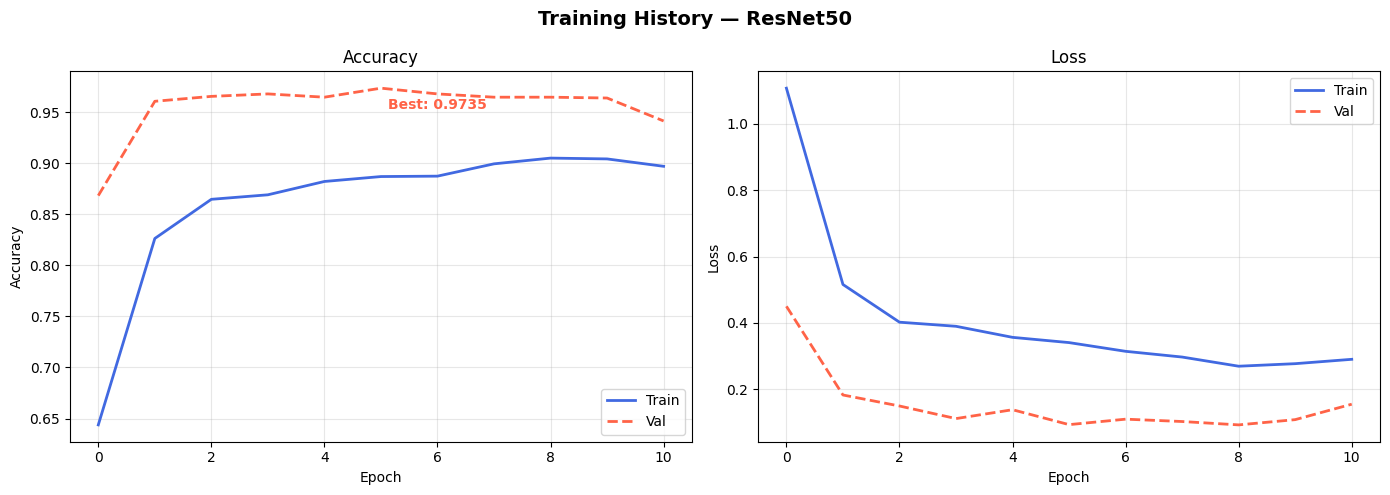

  Saved → results\ResNet50_history.png


In [19]:
plot_history('ResNet50')

Evaluating ResNet50: 100%|██████████| 78/78 [00:12<00:00,  6.32it/s]



── ResNet50 — Classification Report ──
                                  precision    recall  f1-score   support

                     animal fish       0.96      1.00      0.98       214
                animal fish bass       0.00      0.00      0.00         9
   fish sea_food black_sea_sprat       0.98      0.99      0.99       125
   fish sea_food gilt_head_bream       1.00      0.87      0.93        94
   fish sea_food hourse_mackerel       0.94      1.00      0.97       104
        fish sea_food red_mullet       0.97      0.99      0.98       117
     fish sea_food red_sea_bream       0.94      0.99      0.97       117
          fish sea_food sea_bass       0.97      1.00      0.99       108
            fish sea_food shrimp       0.99      1.00      1.00       123
fish sea_food striped_red_mullet       1.00      0.93      0.97       119
             fish sea_food trout       1.00      0.99      1.00       115

                        accuracy                           0.97      1

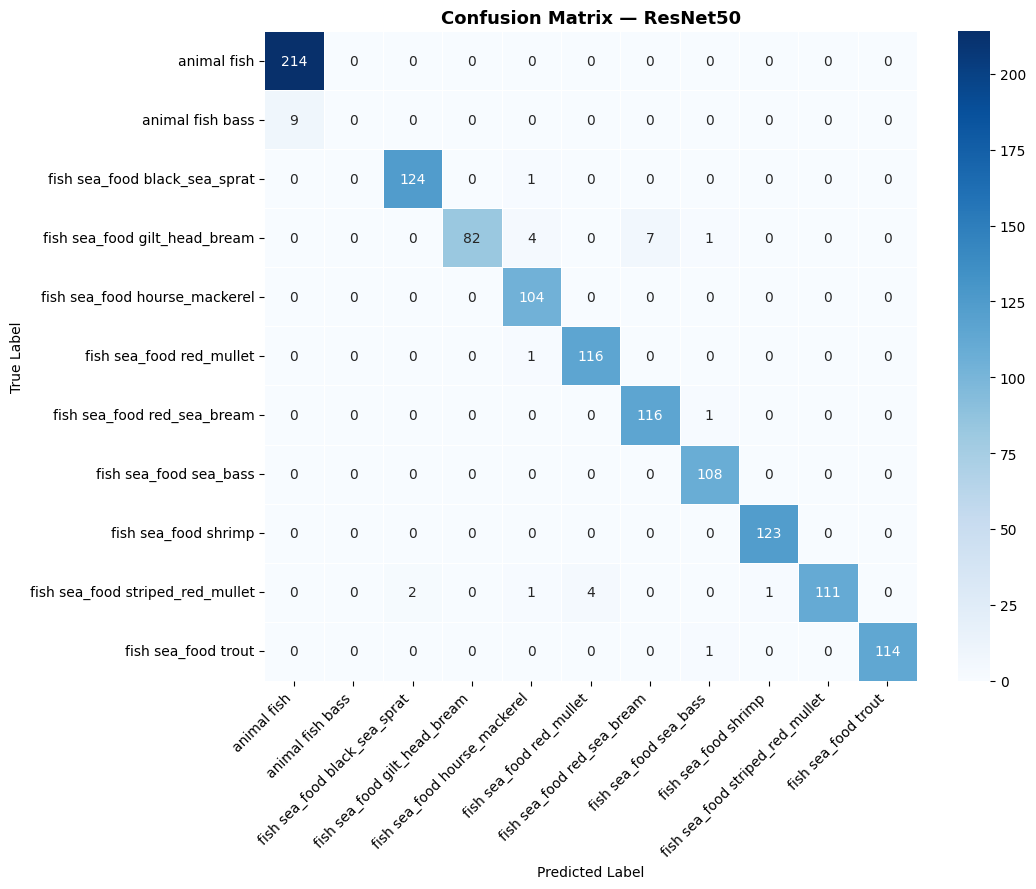

  Saved → results\ResNet50_confusion_matrix.png
GPU cache cleared ✅


In [20]:
evaluate_model(resnet50, 'ResNet50')
clear_gpu()

## ✅ Step 10 — Model 4: MobileNetV2

In [21]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
for param in mobilenet.parameters():
    param.requires_grad = False
# Replace classifier
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, NUM_CLASSES)

mobilenet, _ = train_model(mobilenet, 'MobileNetV2')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\sarav/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:03<00:00, 4.63MB/s]



  Training : MobileNetV2
  Params   : 14,091
  Device   : cuda


Epoch 01/20 | Train Loss: 0.8111 Acc: 0.7831 | Val Loss: 0.2880 Acc: 0.9590


Epoch 02/20 | Train Loss: 0.3426 Acc: 0.9028 | Val Loss: 0.1886 Acc: 0.9622


Epoch 03/20 | Train Loss: 0.2572 Acc: 0.9243 | Val Loss: 0.1238 Acc: 0.9791


...

Epoch 16/20 | Train Loss: 0.1281 Acc: 0.9574 | Val Loss: 0.0420 Acc: 0.9904


Epoch 17/20 | Train Loss: 0.1291 Acc: 0.9548 | Val Loss: 0.0390 Acc: 0.9904


Epoch 18/20 | Train Loss: 0.1276 Acc: 0.9556 | Val Loss: 0.0324 Acc: 0.9936


Epoch 19/20 | Train Loss: 0.1324 Acc: 0.9548 | Val Loss: 0.0690 Acc: 0.9799


Epoch 20/20 | Train Loss: 0.1513 Acc: 0.9468 | Val Loss: 0.0468 Acc: 0.9863
  Best Val Accuracy : 0.9936


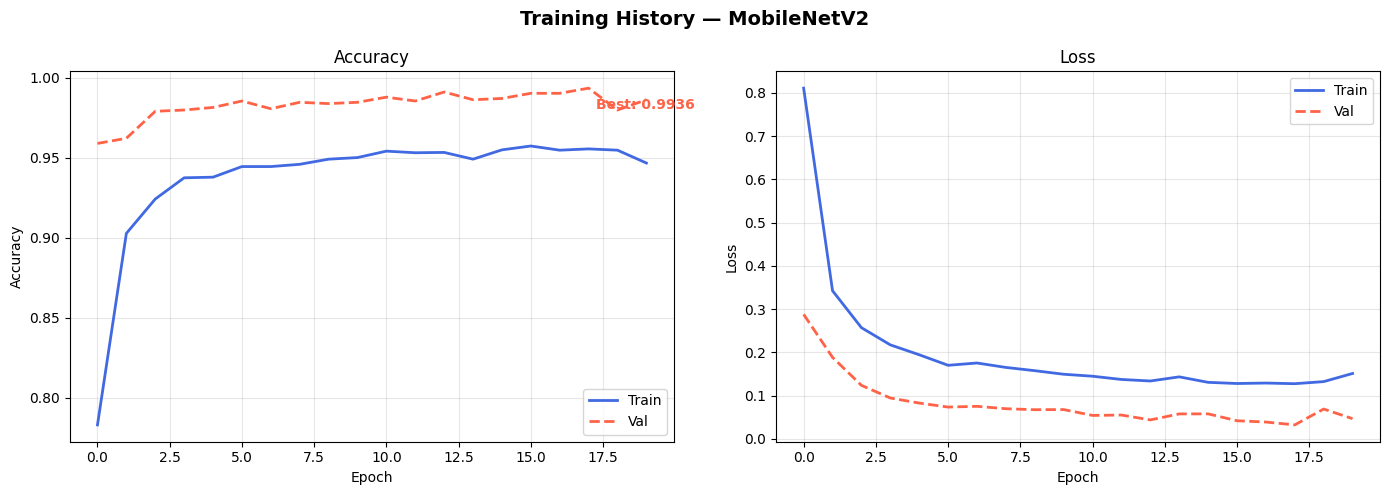

  Saved → results\MobileNetV2_history.png


In [22]:
plot_history('MobileNetV2')

Evaluating MobileNetV2: 100%|██████████| 78/78 [00:10<00:00,  7.53it/s]



── MobileNetV2 — Classification Report ──
                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      1.00       214
                animal fish bass       1.00      0.78      0.88         9
   fish sea_food black_sea_sprat       1.00      1.00      1.00       125
   fish sea_food gilt_head_bream       0.99      0.98      0.98        94
   fish sea_food hourse_mackerel       0.99      0.99      0.99       104
        fish sea_food red_mullet       1.00      1.00      1.00       117
     fish sea_food red_sea_bream       0.98      0.99      0.99       117
          fish sea_food sea_bass       0.98      1.00      0.99       108
            fish sea_food shrimp       1.00      1.00      1.00       123
fish sea_food striped_red_mullet       1.00      1.00      1.00       119
             fish sea_food trout       1.00      0.98      0.99       115

                        accuracy                           0.99    

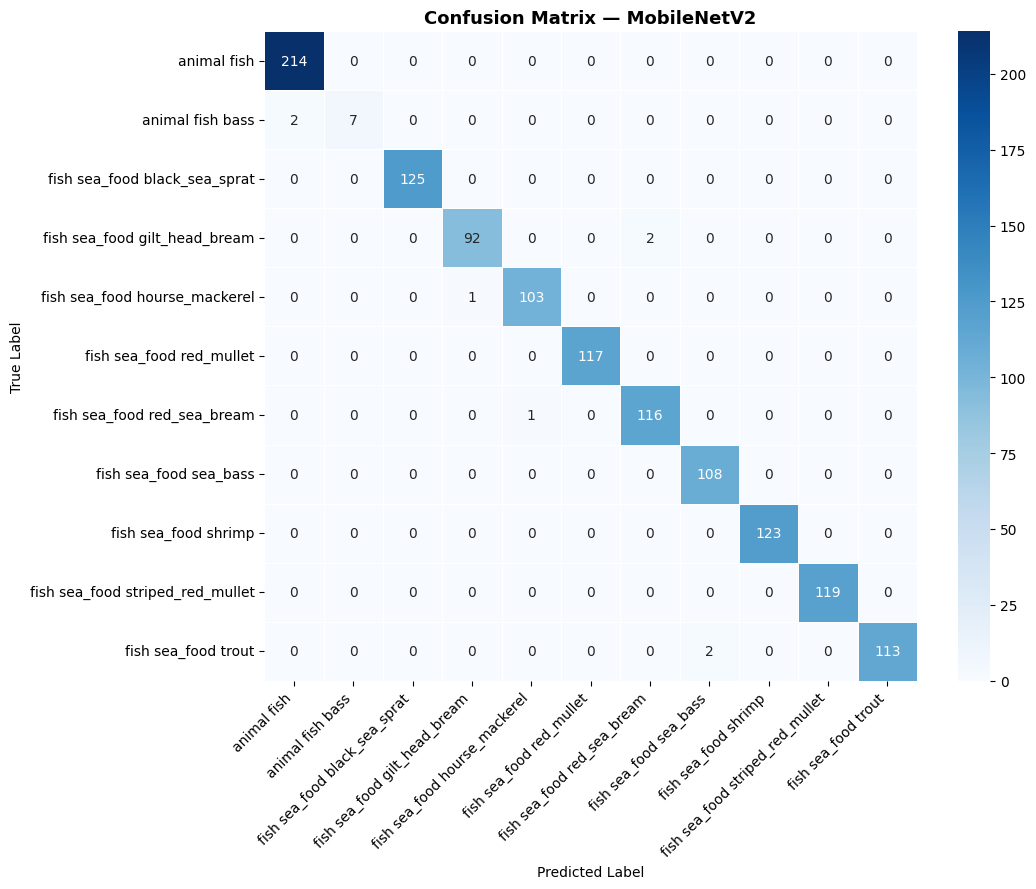

  Saved → results\MobileNetV2_confusion_matrix.png
GPU cache cleared ✅


In [23]:
evaluate_model(mobilenet, 'MobileNetV2')
clear_gpu()

## ✅ Step 11 — Model 5: InceptionV3

In [24]:
# InceptionV3 needs 299x299 — build separate loaders
inception_transforms_train = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
inception_transforms_val = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

inc_train_ds = datasets.ImageFolder(DATASET_DIR, transform=inception_transforms_train)
inc_val_ds   = datasets.ImageFolder(DATASET_DIR, transform=inception_transforms_val)

inc_train_loader = DataLoader(torch.utils.data.Subset(inc_train_ds, train_dataset.indices),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
inc_val_loader   = DataLoader(torch.utils.data.Subset(inc_val_ds, val_dataset.indices),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
for param in inception.parameters():
    param.requires_grad = False
inception.fc     = nn.Linear(inception.fc.in_features, NUM_CLASSES)
inception.AuxLogits.fc = nn.Linear(inception.AuxLogits.fc.in_features, NUM_CLASSES)

# Custom train for inception (handles aux output)
inception = inception.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, inception.parameters()), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

inc_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_inc_acc = 0.0
best_inc_weights = copy.deepcopy(inception.state_dict())
patience_counter = 0

print('Training InceptionV3...')
for epoch in range(EPOCHS):
    inception.train()
    t_loss, t_correct = 0.0, 0
    for inputs, labels in tqdm(inc_train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs, aux = inception(inputs)
        loss = criterion(outputs, labels) + 0.4 * criterion(aux, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * inputs.size(0)
        t_correct += (outputs.argmax(1) == labels).sum().item()

    inception.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in inc_val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = inception(inputs)
            loss    = criterion(outputs, labels)
            v_loss    += loss.item() * inputs.size(0)
            v_correct += (outputs.argmax(1) == labels).sum().item()

    ta = t_correct / train_size
    va = v_correct / val_size
    tl = t_loss / train_size
    vl = v_loss / val_size

    inc_history['train_loss'].append(tl)
    inc_history['train_acc'].append(ta)
    inc_history['val_loss'].append(vl)
    inc_history['val_acc'].append(va)
    scheduler.step(vl)

    print(f'Epoch {epoch+1:02d} | Train Acc: {ta:.4f} | Val Acc: {va:.4f}')

    if va > best_inc_acc:
        best_inc_acc = va
        best_inc_weights = copy.deepcopy(inception.state_dict())
        torch.save(inception.state_dict(), os.path.join(MODEL_SAVE_DIR, 'InceptionV3.pth'))
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= 5:
        print('Early stopping!')
        break

inception.load_state_dict(best_inc_weights)
all_histories['InceptionV3'] = inc_history
model_map['InceptionV3']     = inception
print(f'Best Val Accuracy: {best_inc_acc:.4f}')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\sarav/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:29<00:00, 3.67MB/s] 


Training InceptionV3...


Epoch 01 | Train Acc: 0.7283 | Val Acc: 0.9422


Epoch 02 | Train Acc: 0.8749 | Val Acc: 0.9550


Epoch 03 | Train Acc: 0.8926 | Val Acc: 0.9655


...

Epoch 10 | Train Acc: 0.9215 | Val Acc: 0.9823


Epoch 11 | Train Acc: 0.9211 | Val Acc: 0.9799


Epoch 12 | Train Acc: 0.9331 | Val Acc: 0.9847


Epoch 13 | Train Acc: 0.9321 | Val Acc: 0.9775


Epoch 14 | Train Acc: 0.9289 | Val Acc: 0.9863
Early stopping!
Best Val Accuracy: 0.9880


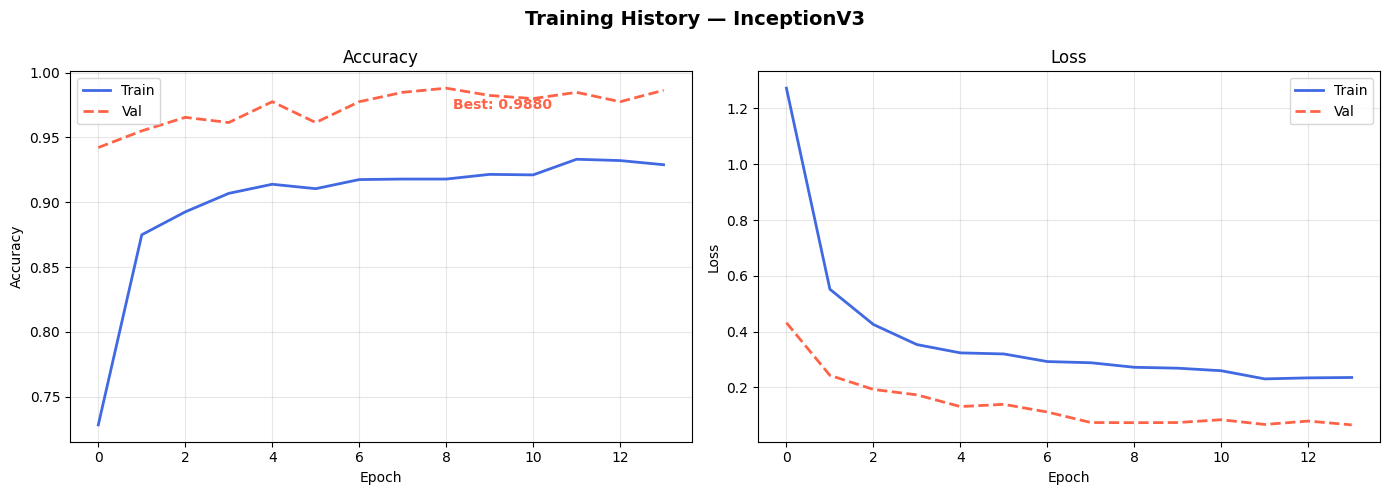

  Saved → results\InceptionV3_history.png


In [25]:
plot_history('InceptionV3')

Evaluating InceptionV3: 100%|██████████| 78/78 [00:15<00:00,  5.19it/s]


                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       214
                animal fish bass       1.00      0.78      0.88         9
   fish sea_food black_sea_sprat       0.99      1.00      1.00       125
   fish sea_food gilt_head_bream       1.00      0.96      0.98        94
   fish sea_food hourse_mackerel       0.99      1.00      1.00       104
        fish sea_food red_mullet       0.97      0.97      0.97       117
     fish sea_food red_sea_bream       0.99      1.00      1.00       117
          fish sea_food sea_bass       0.99      0.99      0.99       108
            fish sea_food shrimp       1.00      0.99      1.00       123
fish sea_food striped_red_mullet       0.96      0.97      0.97       119
             fish sea_food trout       0.99      1.00      1.00       115

                        accuracy                           0.99      1245
                       macro avg    

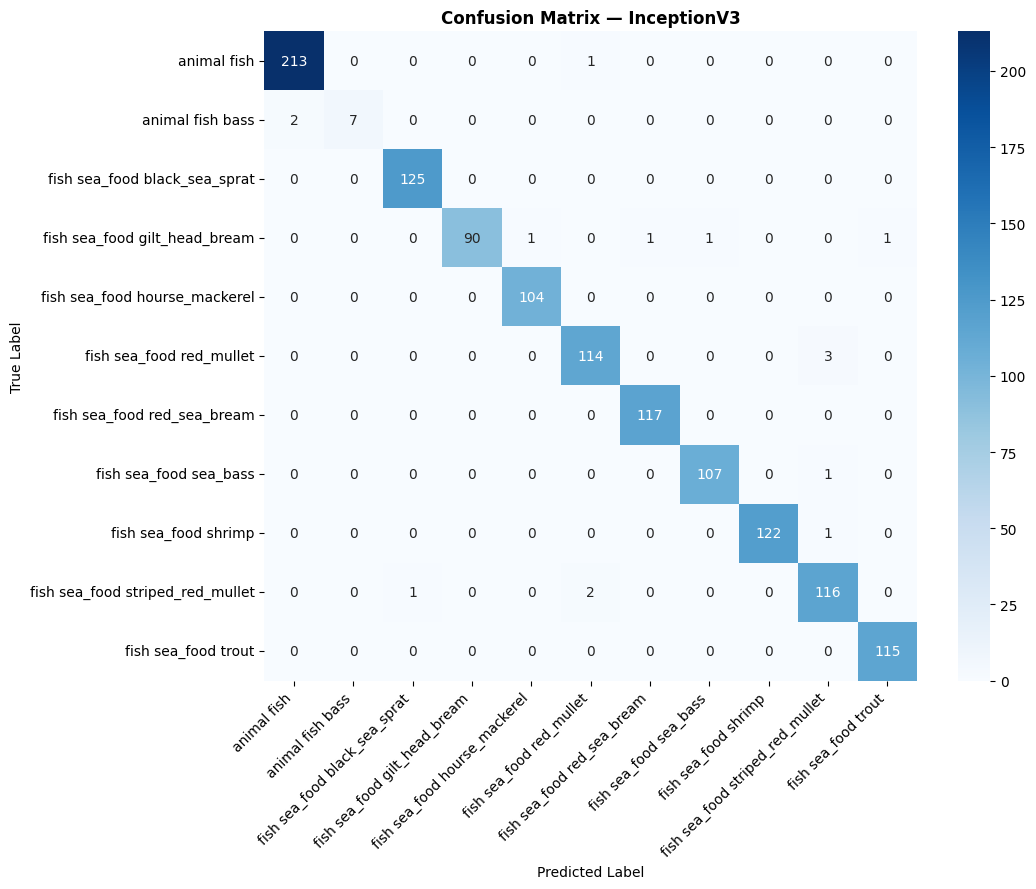

GPU cache cleared ✅


In [26]:
# Evaluate InceptionV3 using its val loader
inception.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(inc_val_loader, desc='Evaluating InceptionV3'):
        outputs = inception(inputs.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

report_inc = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES-2)))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, cmap='Blues')
plt.title('Confusion Matrix — InceptionV3', fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'InceptionV3_confusion_matrix.png'), dpi=120)
plt.show()
all_reports['InceptionV3'] = report_inc
clear_gpu()

## ✅ Step 12 — Model 6: EfficientNetB0

In [27]:
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in efficientnet.parameters():
    param.requires_grad = False
# Replace classifier
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, NUM_CLASSES)

efficientnet, _ = train_model(efficientnet, 'EfficientNetB0')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\sarav/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:05<00:00, 4.19MB/s]



  Training : EfficientNetB0
  Params   : 14,091
  Device   : cuda


Epoch 01/20 | Train Loss: 0.8948 Acc: 0.8122 | Val Loss: 0.4023 Acc: 0.9574


Epoch 02/20 | Train Loss: 0.3885 Acc: 0.9139 | Val Loss: 0.2928 Acc: 0.9462


Epoch 03/20 | Train Loss: 0.2911 Acc: 0.9267 | Val Loss: 0.2110 Acc: 0.9606


...

Epoch 11/20 | Train Loss: 0.1524 Acc: 0.9518 | Val Loss: 0.0877 Acc: 0.9807


Epoch 12/20 | Train Loss: 0.1377 Acc: 0.9592 | Val Loss: 0.0853 Acc: 0.9791


Epoch 13/20 | Train Loss: 0.1308 Acc: 0.9602 | Val Loss: 0.0781 Acc: 0.9767


Epoch 14/20 | Train Loss: 0.1384 Acc: 0.9578 | Val Loss: 0.0886 Acc: 0.9751


Epoch 15/20 | Train Loss: 0.1360 Acc: 0.9544 | Val Loss: 0.0792 Acc: 0.9799
  Early stopping at epoch 15
  Best Val Accuracy : 0.9855


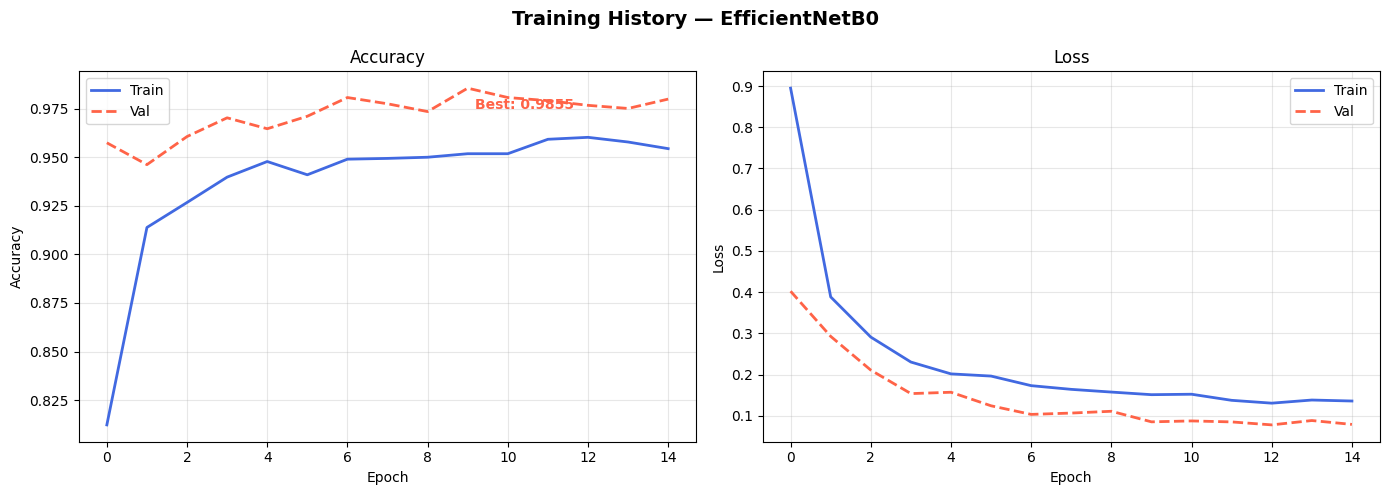

  Saved → results\EfficientNetB0_history.png


In [28]:
plot_history('EfficientNetB0')

Evaluating EfficientNetB0: 100%|██████████| 78/78 [00:08<00:00,  8.85it/s]



── EfficientNetB0 — Classification Report ──
                                  precision    recall  f1-score   support

                     animal fish       0.98      1.00      0.99       214
                animal fish bass       1.00      0.44      0.62         9
   fish sea_food black_sea_sprat       1.00      1.00      1.00       125
   fish sea_food gilt_head_bream       0.99      0.96      0.97        94
   fish sea_food hourse_mackerel       0.97      0.99      0.98       104
        fish sea_food red_mullet       0.98      0.99      0.99       117
     fish sea_food red_sea_bream       0.99      0.99      0.99       117
          fish sea_food sea_bass       0.97      1.00      0.99       108
            fish sea_food shrimp       0.99      1.00      1.00       123
fish sea_food striped_red_mullet       0.99      0.97      0.98       119
             fish sea_food trout       0.99      0.97      0.98       115

                        accuracy                           0.99 

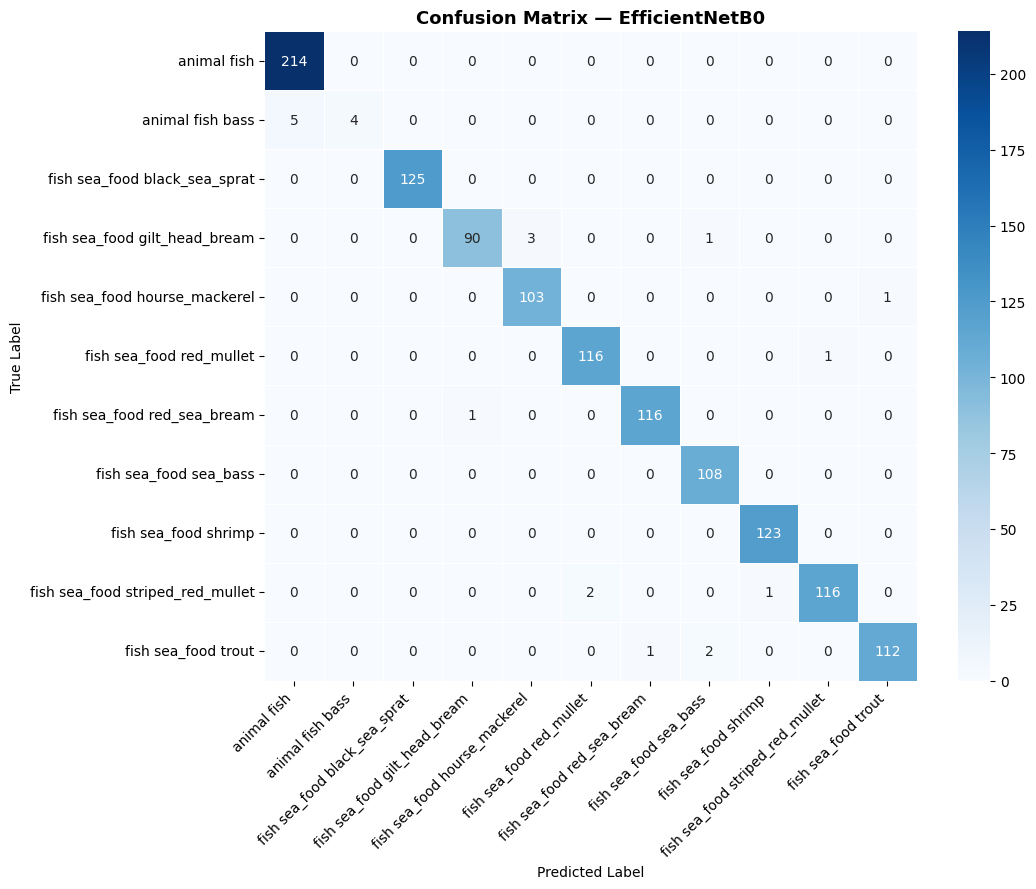

  Saved → results\EfficientNetB0_confusion_matrix.png
GPU cache cleared ✅


In [29]:
evaluate_model(efficientnet, 'EfficientNetB0')
clear_gpu()

## ✅ Step 13 — Combined Training History (All Models)

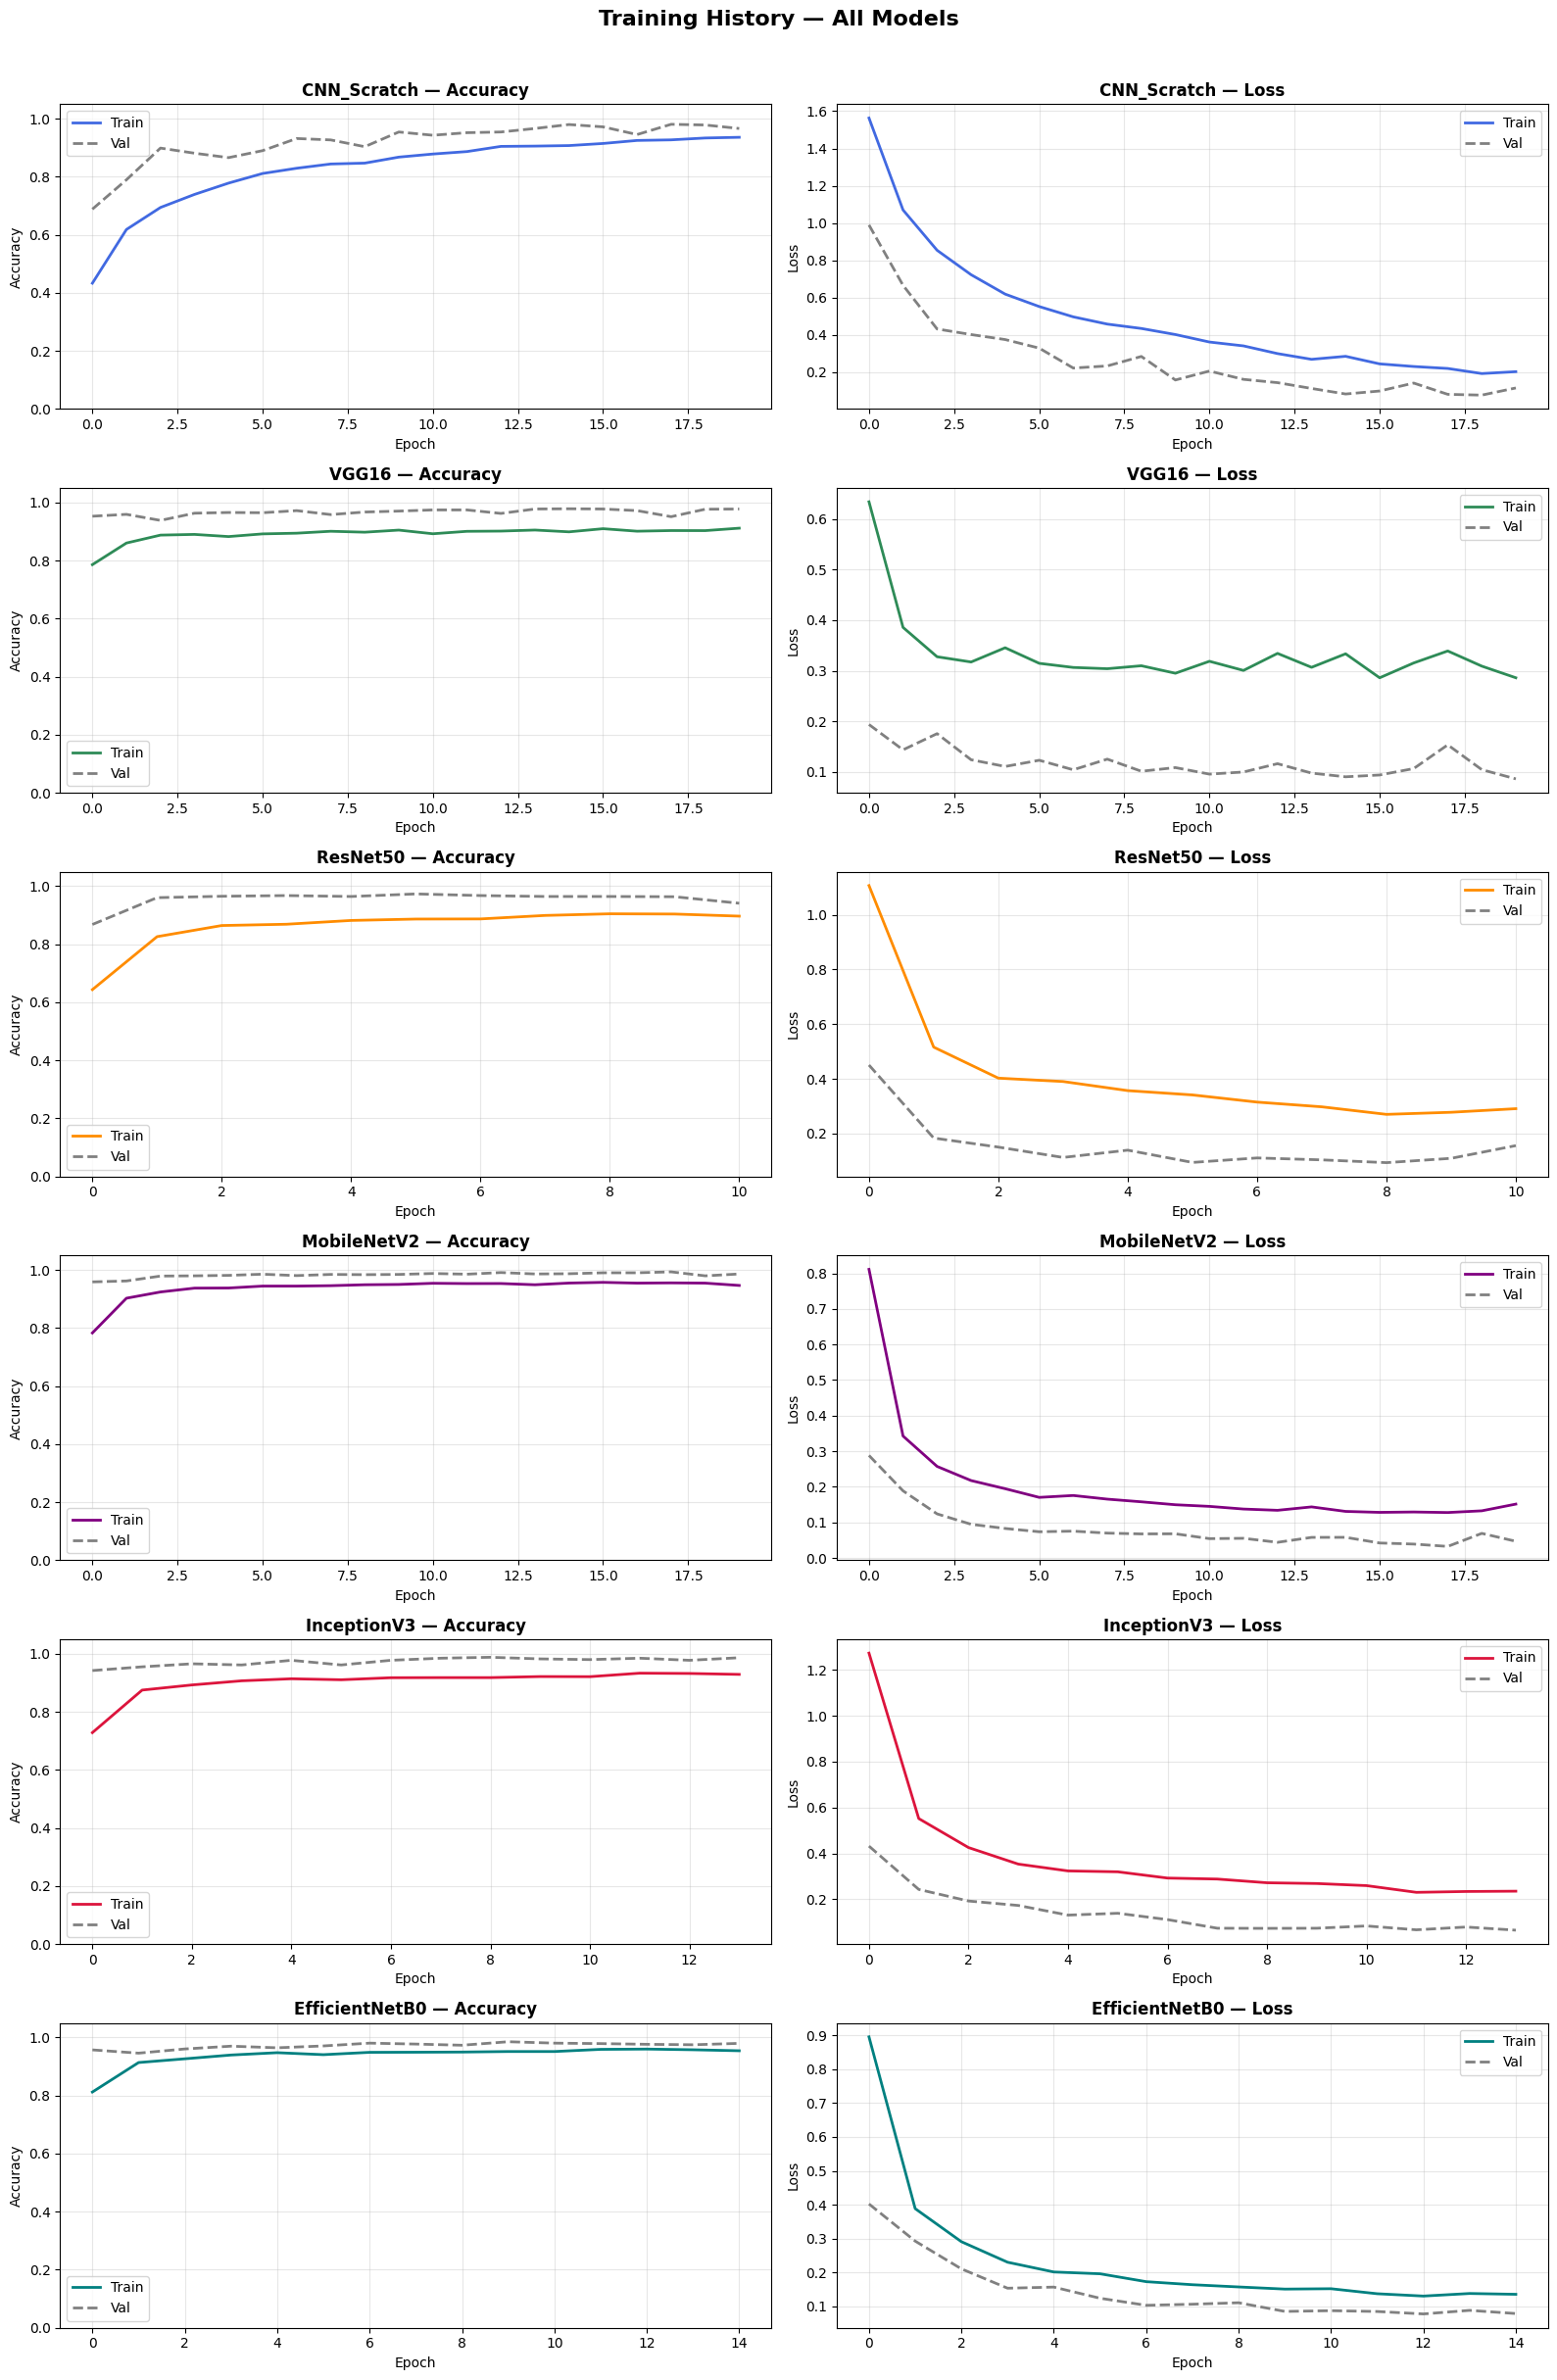

Saved → results\all_models_history.png ✅


In [30]:
model_names = list(all_histories.keys())
n      = len(model_names)
colors = ['royalblue', 'seagreen', 'darkorange', 'purple', 'crimson', 'teal']

fig, axes = plt.subplots(n, 2, figsize=(16, n * 4))
fig.suptitle('Training History — All Models', fontsize=16, fontweight='bold', y=1.01)

for i, name in enumerate(model_names):
    hist = all_histories[name]
    c    = colors[i % len(colors)]

    axes[i][0].plot(hist['train_acc'], label='Train', color=c,      linewidth=2)
    axes[i][0].plot(hist['val_acc'],   label='Val',   color='gray', linewidth=2, linestyle='--')
    axes[i][0].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i][0].set_xlabel('Epoch'); axes[i][0].set_ylabel('Accuracy')
    axes[i][0].set_ylim(0, 1.05); axes[i][0].legend(); axes[i][0].grid(alpha=0.3)

    axes[i][1].plot(hist['train_loss'], label='Train', color=c,      linewidth=2)
    axes[i][1].plot(hist['val_loss'],   label='Val',   color='gray', linewidth=2, linestyle='--')
    axes[i][1].set_title(f'{name} — Loss', fontweight='bold')
    axes[i][1].set_xlabel('Epoch'); axes[i][1].set_ylabel('Loss')
    axes[i][1].legend(); axes[i][1].grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'all_models_history.png')
plt.savefig(path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {path} ✅')

## ✅ Step 14 — Model Comparison Report

In [31]:
rows = [
    {
        'Model':     name,
        'Accuracy':  round(rpt['accuracy'], 4),
        'Precision': round(rpt['weighted avg']['precision'], 4),
        'Recall':    round(rpt['weighted avg']['recall'], 4),
        'F1-Score':  round(rpt['weighted avg']['f1-score'], 4),
    }
    for name, rpt in all_reports.items()
]

comparison_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df.to_json(os.path.join(RESULTS_DIR, 'comparison_report.json'), orient='records', indent=2)

display(
    comparison_df.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score'], color='lightgreen')
    .highlight_min(subset=['Accuracy','Precision','Recall','F1-Score'], color='#ffcccc')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-Score':'{:.4f}'})
    .set_caption('🏆 Model Comparison — Green = Best | Red = Lowest')
)

,Model,Accuracy,Precision,Recall,F1-Score
0,MobileNetV2,0.9936,0.9936,0.9936,0.9935
1,InceptionV3,0.9880,0.9881,0.9880,0.9879
2,EfficientNetB0,0.9855,0.9857,0.9855,0.9848
3,CNN_Scratch,0.9807,0.9741,0.9807,0.9770
4,VGG16,0.9783,0.9787,0.9783,0.9772
5,ResNet50,0.9735,0.9674,0.9735,0.9697


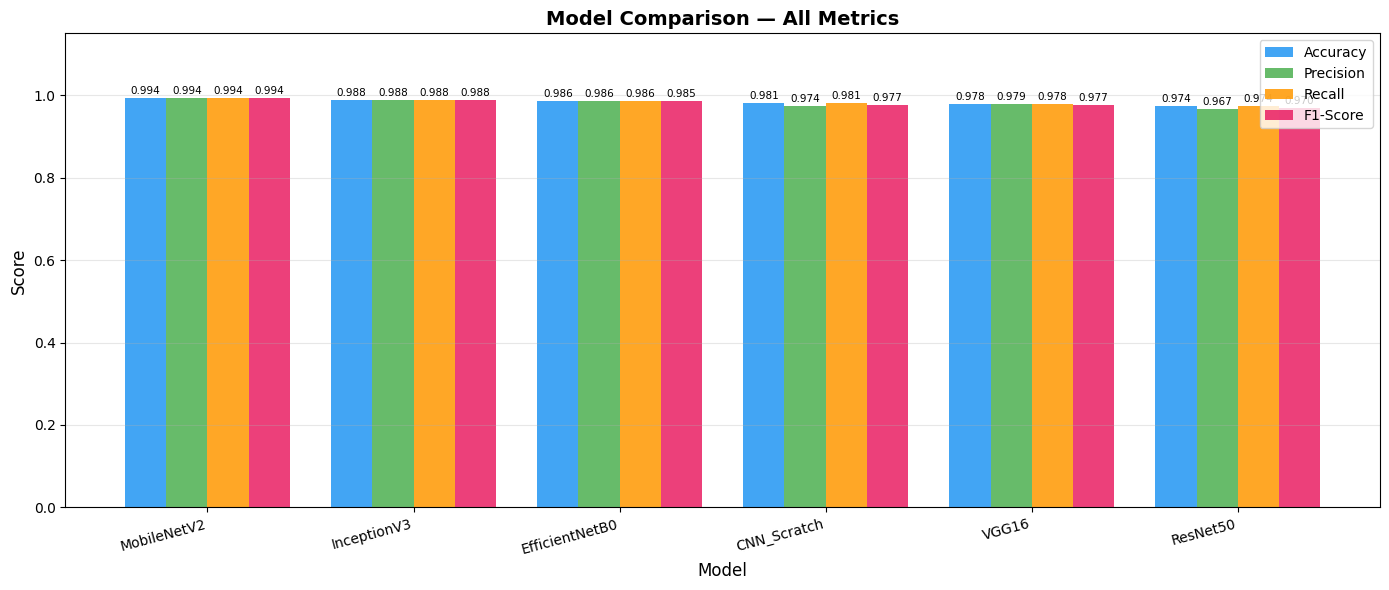

In [32]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x          = np.arange(len(comparison_df))
width      = 0.2
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax.bar(x + i * width, comparison_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score',  fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison_chart.png'), dpi=120)
plt.show()

## ✅ Step 15 — Save Best Model

In [33]:
best_name  = comparison_df.iloc[0]['Model']
best_acc   = comparison_df.iloc[0]['Accuracy']
best_model = model_map[best_name]

# Save full model (architecture + weights)
torch.save(best_model, os.path.join(MODEL_SAVE_DIR, 'best_model_full.pth'))
# Save weights only
torch.save(best_model.state_dict(), os.path.join(MODEL_SAVE_DIR, 'best_model_weights.pth'))

with open(os.path.join(MODEL_SAVE_DIR, 'best_model_name.json'), 'w') as f:
    json.dump({'best_model': best_name, 'accuracy': float(best_acc)}, f)

print(f'🏆 Best Model : {best_name}')
print(f'   Accuracy   : {best_acc:.4f}')
print(f'   Saved to   : {MODEL_SAVE_DIR}/')

🏆 Best Model : MobileNetV2
   Accuracy   : 0.9936
   Saved to   : saved_models/


## ✅ Step 16 — Test Single Image Prediction

In [34]:
def predict_image(img_path, model=None):
    if model is None:
        model = torch.load(os.path.join(MODEL_SAVE_DIR, 'best_model_full.pth'))
    model.eval().to(DEVICE)

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    img  = Image.open(img_path).convert('RGB')
    inp  = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out   = model(inp)
        probs = torch.softmax(out, dim=1).cpu().numpy()[0]

    top_idx   = int(np.argmax(probs))
    top_class = CLASS_NAMES[top_idx]
    top_conf  = float(probs[top_idx])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'Prediction : {top_class}\nConfidence : {top_conf*100:.2f}%',
                      fontsize=12, fontweight='bold', color='darkgreen')
    axes[0].axis('off')

    top_n      = min(10, len(CLASS_NAMES))
    sorted_idx = np.argsort(probs)[::-1][:top_n]
    bar_cols   = ['#2ecc71' if i == top_idx else '#3498db' for i in sorted_idx]
    axes[1].barh([CLASS_NAMES[i] for i in sorted_idx[::-1]],
                 [probs[i]       for i in sorted_idx[::-1]],
                 color=bar_cols[::-1])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top Class Probabilities')
    axes[1].grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return top_class, top_conf


# Update this path to any fish image
TEST_IMAGE = r'C:\Users\sarav\Documents\CV_project\Fish_classification\data\train\<FishClass>\any_image.jpg'

if os.path.exists(TEST_IMAGE):
    cls, conf = predict_image(TEST_IMAGE, best_model)
    print(f'\n🐠 Predicted : {cls}  |  Confidence : {conf*100:.2f}%')
else:
    print('Update TEST_IMAGE path above with a real image path.')

Update TEST_IMAGE path above with a real image path.


## ✅ Step 17 — Generate Streamlit App
> After running this cell, open terminal and run: `streamlit run app.py`

In [2]:
!pip install plotly

     ---------------------------------------- 9.9/9.9 MB 11.7 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\sarav\Documents\CV_project\Fish_classification\env\Scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
app_code = '''
import os, json
import numpy as np
from PIL import Image
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms
import pandas as pd
import plotly.graph_objects as go

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "saved_models/best_model_full.pth"
NAMES_PATH = "saved_models/class_names.json"
RESULTS    = "results"
IMG_SIZE   = 224

st.set_page_config(page_title="Fish Classifier", page_icon="🐟", layout="wide")

@st.cache_resource
def load_model():
    model = torch.load(MODEL_PATH, map_location=DEVICE)
    model.eval()
    return model

@st.cache_data
def load_names():
    with open(NAMES_PATH) as f: return json.load(f)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

with st.sidebar:
    st.title("🐟 Fish Classifier")
    st.markdown(f"**Device:** {DEVICE}")
    info_path = "saved_models/best_model_name.json"
    if os.path.exists(info_path):
        with open(info_path) as f: info = json.load(f)
        st.success(f"Best Model: {info[\'best_model\']}")
        st.metric("Val Accuracy", f"{info[\'accuracy\']*100:.2f}%")
    page = st.radio("Navigate", ["🔍 Predict", "📊 Comparison", "📈 History"])

model, class_names = load_model(), load_names()

if page == "🔍 Predict":
    st.title("🐟 Fish Species Classifier")
    uploaded = st.file_uploader("Upload a fish image", type=["jpg","jpeg","png"])
    if uploaded:
        img = Image.open(uploaded).convert("RGB")
        col1, col2 = st.columns(2)
        with col1:
            st.image(img, caption="Uploaded Image", use_container_width=True)
        with col2:
            inp  = transform(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out   = model(inp)
                probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            idx = int(np.argmax(probs))
            st.success(f"**Prediction: {class_names[idx]}**")
            st.metric("Confidence", f"{probs[idx]*100:.2f}%")
            st.progress(float(probs[idx]))
            fig = go.Figure(go.Bar(
                x=list(probs), y=class_names, orientation="h",
                marker_color=["#2ecc71" if i==idx else "#3498db" for i in range(len(class_names))],
                text=[f"{v*100:.1f}%" for v in probs], textposition="outside"
            ))
            fig.update_layout(title="Class Probabilities", xaxis_range=[0,1.2],
                              height=max(400, len(class_names)*35))
            st.plotly_chart(fig, use_container_width=True)

elif page == "📊 Comparison":
    st.title("📊 Model Comparison")
    rpt_path = os.path.join(RESULTS, "comparison_report.json")
    if os.path.exists(rpt_path):
        df = pd.read_json(rpt_path)
        st.dataframe(df.style.highlight_max(subset=["Accuracy","Precision","Recall","F1-Score"],
                     color="lightgreen"), use_container_width=True)
        chart = os.path.join(RESULTS, "model_comparison_chart.png")
        if os.path.exists(chart): st.image(chart, use_container_width=True)
    else:
        st.warning("Run the notebook first to generate results.")

elif page == "📈 History":
    st.title("📈 Training History")
    all_hist = os.path.join(RESULTS, "all_models_history.png")
    if os.path.exists(all_hist):
        st.image(all_hist, caption="All Models", use_container_width=True)
    for hf in sorted(f for f in os.listdir(RESULTS) if f.endswith("_history.png") and "all" not in f):
        st.markdown(f"**{hf.replace(\'_history.png\', \'\')}**")
        st.image(os.path.join(RESULTS, hf), use_container_width=True)
'''



# After (fixed)
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code.strip()) 
    print('✅ app.py created!')
    print('Run in terminal: streamlit run app.py')

✅ app.py created!
Run in terminal: streamlit run app.py


---
## 🎉 All Done!

| Step | Task | Status |
|---|---|---|
| 1 | PyTorch + CUDA 12.5 GPU setup | ✅ |
| 2 | Data Preprocessing & Augmentation | ✅ |
| 3 | CNN from Scratch | ✅ |
| 4 | VGG16 Transfer Learning | ✅ |
| 5 | ResNet50 Transfer Learning | ✅ |
| 6 | MobileNetV2 Transfer Learning | ✅ |
| 7 | InceptionV3 Transfer Learning | ✅ |
| 8 | EfficientNetB0 Transfer Learning | ✅ |
| 9 | Training History Plots | ✅ |
| 10 | Confusion Matrices | ✅ |
| 11 | Model Comparison Report | ✅ |
| 12 | Best Model Saved (.pth) | ✅ |
| 13 | Streamlit App (app.py) | ✅ |